In [ ]:
!pip install scikit-learn

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_parquet("reddit_MensRights_madoc.parquet")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3110425 entries, 0 to 3110424
Data columns (total 13 columns):
 #   Column            Dtype  
---  ------            -----  
 0   post_id           object 
 1   publish_date      int64  
 2   user_id           object 
 3   parent_id         object 
 4   parent_user_id    object 
 5   content           string 
 6   url               object 
 7   language          string 
 8   interaction_type  string 
 9   platform          object 
 10  community         object 
 11  strict_filter     object 
 12  sentiment_vader   float64
dtypes: float64(1), int64(1), object(8), string(3)
memory usage: 308.5+ MB


In [6]:
df['publish_date'] = pd.to_datetime(df['publish_date'], unit='s', utc=True)

In [7]:
df["month"] = df["publish_date"].dt.month
df["year"] = df["publish_date"].dt.year

In [8]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def compute_user_features(df_month):
    # --- 1. Активность и структура ---
    agg_activity = df_month.groupby('user_id').agg(
        activity=('post_id', 'count'),
        comments_ratio=('interaction_type', lambda x: (x == 'COMMENT').mean()),
        reposts_ratio=('interaction_type', lambda x: (x == 'REPOST').mean()),
        active_days=('publish_date', lambda x: pd.to_datetime(x, unit='s').dt.date.nunique()),
        unique_parents=('parent_user_id', 'nunique'),
        same_community_ratio=('community', lambda x: (x == x.mode()[0]).mean() if not x.mode().empty else 0)
    )

    # --- 2. Эмоции ---
    agg_emotion = df_month.groupby('user_id').agg(
        mean_sentiment=('sentiment_vader', 'mean'),
        std_sentiment=('sentiment_vader', 'std'),
        neg_ratio=('sentiment_vader', lambda x: (x < -0.05).mean()),
        pos_ratio=('sentiment_vader', lambda x: (x > 0.05).mean())
    )
    agg_emotion['emotion_polarization'] = np.abs(agg_emotion['pos_ratio'] - agg_emotion['neg_ratio'])

    # --- 3. Токсичность / строгий фильтр ---
    agg_toxic = df_month.groupby('user_id').agg(
        toxic_ratio=('strict_filter', 'mean'),
        toxic_neg_interaction=('sentiment_vader', lambda x: ((x < 0) & (df_month.loc[x.index, 'strict_filter'] == 1)).mean())
    )

    # --- 4. Лексическое разнообразие ---
    def unique_words_ratio(texts):
        words = " ".join(texts).lower().split()
        return len(set(words)) / max(len(words), 1)

    agg_lex = df_month.groupby('user_id').agg(
        unique_words_ratio=('content', unique_words_ratio)
    )

    # --- 5. Самоподобие сообщений ---
    def self_similarity(texts):
        texts = [str(t) for t in texts if str(t).strip()] 
        if len(texts) < 2:
            return 0.0
        try:
            vectorizer = CountVectorizer()
            X = vectorizer.fit_transform(texts)
            if X.shape[1] == 0:  # словарь пуст
                return 0.0
            sim_matrix = cosine_similarity(X)
            triu_indices = np.triu_indices_from(sim_matrix, k=1)
            return sim_matrix[triu_indices].mean() if len(triu_indices[0]) > 0 else 0.0
        except ValueError:
            return 0.0

    agg_similarity = df_month.groupby('user_id').agg(
        self_similarity=('content', self_similarity)
    )

    # --- объединяем все признаки ---
    user_features = pd.concat(
        [agg_activity, agg_emotion, agg_toxic, agg_lex, agg_similarity],
        axis=1
    ).fillna(0)

    user_features.reset_index(inplace=True)
    return user_features

In [9]:
monthly_user_features = []

for (y, m), df_m in df.groupby(['year', 'month']):
    features = compute_user_features(df_m)
    features['year'] = y
    features['month'] = m
    monthly_user_features.append(features)

user_features_all_months = pd.concat(monthly_user_features, ignore_index=True)
user_features_all_months.head()

C:\Users\Лиана\AppData\Local\Temp\ipykernel_17100\1768143547.py:65: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(0)
C:\Users\Лиана\AppData\Local\Temp\ipykernel_17100\1768143547.py:65: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(0)
C:\Users\Лиана\AppData\Local\Temp\ipykernel_17100\1768143547.py:65: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_sile

,user_id,activity,comments_ratio,reposts_ratio,active_days,unique_parents,same_community_ratio,mean_sentiment,std_sentiment,neg_ratio,pos_ratio,emotion_polarization,toxic_ratio,toxic_neg_interaction,unique_words_ratio,self_similarity,year,month
0,000eb2f0-8629-5564-b5c4-a6e37e31e3de,2,1.0,0.0,1,0,1.0,-0.190900,0.269973,0.500000,0.000000,0.500000,0,0.0,0.760000,0.257248,2014,1
1,0014b13a-78d1-5b3d-bdca-6bad26de7dba,6,1.0,0.0,2,0,1.0,-0.542183,0.485480,0.833333,0.166667,0.666667,0,0.0,0.581769,0.127200,2014,1
2,00307e23-310d-552f-932f-3a979dd7cce1,2,1.0,0.0,1,0,1.0,0.190100,0.017253,0.000000,1.000000,1.000000,0,0.0,0.906977,0.055556,2014,1
3,0030a0bb-2f09-552b-8f41-035cbc0c7dc0,6,1.0,0.0,4,2,1.0,0.191450,0.532813,0.333333,0.500000,0.166667,0,0.0,0.697368,0.150561,2014,1
4,003b1aa6-d0f9-5a23-bf57-b71df89ed04e,1,1.0,0.0,1,0,1.0,0.273200,0.000000,0.000000,1.000000,1.000000,0,0.0,0.903226,0.000000,2014,1


In [10]:
from sklearn.preprocessing import StandardScaler

features_cols = [
    'activity', 'comments_ratio', 'reposts_ratio', 'active_days', 'unique_parents', 'same_community_ratio',
    'mean_sentiment', 'std_sentiment', 'neg_ratio', 'pos_ratio', 'emotion_polarization',
    'toxic_ratio', 'toxic_neg_interaction', 'unique_words_ratio', 'self_similarity'
]

scaler = StandardScaler()

user_features_all_months_scaled = user_features_all_months.copy()
user_features_all_months_scaled[features_cols] = scaler.fit_transform(user_features_all_months[features_cols])

In [11]:
# train: 2014-2015
train_mask = (user_features_all_months_scaled['year'] >= 2012) & (user_features_all_months_scaled['year'] <= 2015)
train_df = user_features_all_months_scaled[train_mask]

# test: 2016 и далее
test_mask = user_features_all_months_scaled['year'] > 2015
test_df = user_features_all_months_scaled[test_mask]


In [12]:
import faiss

In [13]:
X_train = train_df[features_cols].values.astype('float32')
n_clusters = 10
kmeans = faiss.Kmeans(d=X_train.shape[1], k=n_clusters, niter=20, verbose=True, seed=42)
kmeans.train(X_train)
_, train_labels = kmeans.index.search(X_train, 1)
train_df['cluster'] = train_labels.flatten()

X_test = test_df[features_cols].values.astype('float32')
_, test_labels = kmeans.index.search(X_test, 1)
test_df['cluster'] = test_labels.flatten()

C:\Users\Лиана\AppData\Local\Temp\ipykernel_17100\1099234870.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['cluster'] = train_labels.flatten()
C:\Users\Лиана\AppData\Local\Temp\ipykernel_17100\1099234870.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['cluster'] = test_labels.flatten()


In [14]:
!pip install seaborn

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

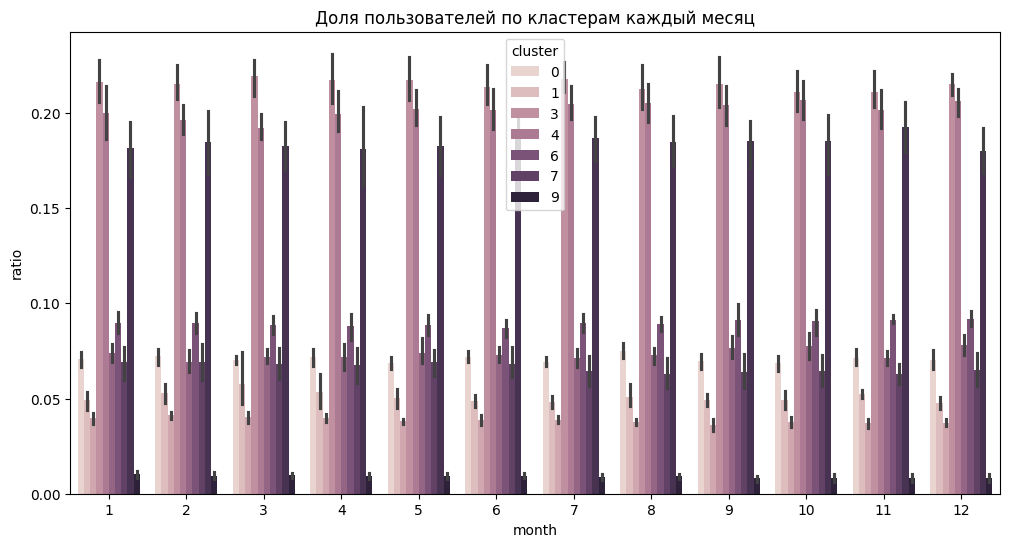

In [16]:
all_df = pd.concat([train_df, test_df])
monthly_counts = all_df.groupby(['year','month','cluster'])['user_id'].count().reset_index()
monthly_counts['ratio'] = monthly_counts.groupby(['year','month'])['user_id'].transform(lambda x: x/x.sum())

plt.figure(figsize=(12,6))
sns.barplot(data=monthly_counts, x='month', y='ratio', hue='cluster')
plt.title('Доля пользователей по кластерам каждый месяц')
plt.show()

In [17]:
start = '2020-01-01'
end   = '2020-01-31'

df_month = df[
    (df['publish_date'] >= start) &
    (df['publish_date'] < end)
].copy()

In [18]:
df_month.shape

(36308, 15)

mean_sentiment — общий эмоциональный фон,

std_sentiment — разнообразие эмоций,

neg_ratio / pos_ratio — перекос,

unique_parents — разнообразие источников взаимодействия

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# --- 1. Активность и структура ---
agg_activity = df_month.groupby('user_id').agg(
    activity=('post_id', 'count'),
    comments_ratio=('interaction_type', lambda x: (x == 'COMMENT').mean()),
    reposts_ratio=('interaction_type', lambda x: (x == 'REPOST').mean()),
    active_days=('publish_date', lambda x: pd.to_datetime(x, unit='s').dt.date.nunique()),
    unique_parents=('parent_user_id', 'nunique'),
    same_community_ratio=('community', lambda x: (x == x.mode()[0]).mean())
)

# --- 2. Эмоции ---
agg_emotion = df_month.groupby('user_id').agg(
    mean_sentiment=('sentiment_vader', 'mean'),
    std_sentiment=('sentiment_vader', 'std'),
    neg_ratio=('sentiment_vader', lambda x: (x < -0.05).mean()),
    pos_ratio=('sentiment_vader', lambda x: (x > 0.05).mean())
)
agg_emotion['emotion_polarization'] = np.abs(agg_emotion['pos_ratio'] - agg_emotion['neg_ratio'])

# --- 3. Токсичность / строгий фильтр ---
agg_toxic = df_month.groupby('user_id').agg(
    toxic_ratio=('strict_filter', 'mean'),
    toxic_neg_interaction=('sentiment_vader', lambda x: ((x < 0) & (df_month.loc[x.index, 'strict_filter'] == 1)).mean())
)

# --- 4. Лексическое разнообразие ---
def unique_words_ratio(texts):
    words = " ".join(texts).lower().split()
    return len(set(words)) / max(len(words), 1)

agg_lex = df_month.groupby('user_id').agg(
    unique_words_ratio=('content', unique_words_ratio)
)

# --- 5. Самоподобие сообщений (косинусная близость) ---
def self_similarity(texts):
    if len(texts) < 2:
        return 0.0
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(texts)
    sim_matrix = cosine_similarity(X)
    # берем среднее по верхнему треугольнику, исключая диагональ
    triu_indices = np.triu_indices_from(sim_matrix, k=1)
    return sim_matrix[triu_indices].mean() if len(triu_indices[0]) > 0 else 0.0

agg_similarity = df_month.groupby('user_id').agg(
    self_similarity=('content', self_similarity)
)

# --- 6. Объединяем все признаки ---
user_features = pd.concat(
    [agg_activity, agg_emotion, agg_toxic, agg_lex, agg_similarity],
    axis=1
).fillna(0)

user_features.reset_index(inplace=True)
user_features.head()


,mean_sentiment,std_sentiment,neg_ratio,pos_ratio,activity,unique_parents
user_id,,,,,,
000c7f95-3db3-5f55-882c-527bbeec0fa2,-0.772400,0.000000,1.000000,0.000000,1,1
0010b71a-7914-50a2-af45-db5e49a72bfb,-0.726900,0.000000,1.000000,0.000000,1,0
002127d9-83a1-53f9-8a67-23aff69716e3,-0.197200,0.484835,0.555556,0.222222,9,3
00259d84-4b16-5d28-8d5d-2a797c00edbe,-0.067496,0.625091,0.470588,0.411765,68,10
0030a0bb-2f09-552b-8f41-035cbc0c7dc0,-0.008875,0.583797,0.500000,0.375000,8,6
...,...,...,...,...,...,...
ffe0f165-bfcf-5ad6-825c-4b3efe8c35cf,-0.444500,0.000000,1.000000,0.000000,1,1
ffe25880-6710-5329-ae10-0e3fca76b85d,-0.154800,0.481671,0.250000,0.250000,4,1
ffe47bc3-704c-52b9-87de-576dda985ccd,0.000000,0.000000,0.000000,0.000000,2,1


In [64]:
all_df

,user_id,activity,comments_ratio,reposts_ratio,active_days,unique_parents,same_community_ratio,mean_sentiment,std_sentiment,neg_ratio,pos_ratio,emotion_polarization,toxic_ratio,toxic_neg_interaction,unique_words_ratio,self_similarity,year,month,cluster
0,000eb2f0-8629-5564-b5c4-a6e37e31e3de,-0.185922,0.310454,0.0,-0.423924,-0.269332,0.0,-0.309100,0.076111,0.196157,-0.930133,-0.130403,0.0,0.0,-0.268088,1.359983,2014,1,5
1,0014b13a-78d1-5b3d-bdca-6bad26de7dba,-0.000950,0.310454,0.0,-0.132471,-0.269332,0.0,-1.148233,0.819786,1.039226,-0.492215,0.262155,0.0,0.0,-1.256928,0.333089,2014,1,5
2,00307e23-310d-552f-932f-3a979dd7cce1,-0.185922,0.310454,0.0,-0.423924,-0.269332,0.0,0.601019,-0.795980,-1.068446,1.697375,1.047269,0.0,0.0,0.547353,-0.232639,2014,1,6
3,0030a0bb-2f09-552b-8f41-035cbc0c7dc0,-0.000950,0.310454,0.0,0.450435,0.089312,0.0,0.604243,0.983124,-0.225377,0.383621,-0.915517,0.0,0.0,-0.615574,0.517554,2014,1,3
4,003b1aa6-d0f9-5a23-bf57-b71df89ed04e,-0.232166,0.310454,0.0,-0.423924,-0.269332,0.0,0.799525,-0.855518,-1.068446,1.697375,1.047269,0.0,0.0,0.526543,-0.671322,2014,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
516631,ff776f17-412e-5cbe-9f96-f786bf4cac2f,-0.232166,-4.124304,0.0,-0.423924,-0.269332,0.0,0.146915,-0.855518,-1.068446,-0.930133,-1.308075,0.0,0.0,1.063455,-0.671322,2020,12,1
516632,ff867124-8122-5236-8052-b12be5006a3a,-0.185922,0.310454,0.0,-0.423924,-0.090010,0.0,0.756766,0.390396,-1.068446,0.383621,-0.130403,0.0,0.0,1.063455,-0.671322,2020,12,8
516633,ffa7b2ac-d5b9-5397-977e-9dad019c48ea,3.559777,0.203593,0.0,3.364963,0.985922,0.0,-0.810482,1.339691,0.851313,-0.296998,-0.087836,0.0,0.0,-3.160675,1.627601,2020,12,7
516634,ffb04122-1f31-589c-a751-f0900b43fbcb,-0.232166,0.310454,0.0,-0.423924,-0.090010,0.0,0.146915,-0.855518,-1.068446,-0.930133,-1.308075,0.0,0.0,1.063455,-0.671322,2020,12,8


c:\Users\Лиана\OneDrive\Desktop\EchoSphere\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Лиана\OneDrive\Desktop\EchoSphere\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Лиана\OneDrive\Desktop\EchoSphere\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


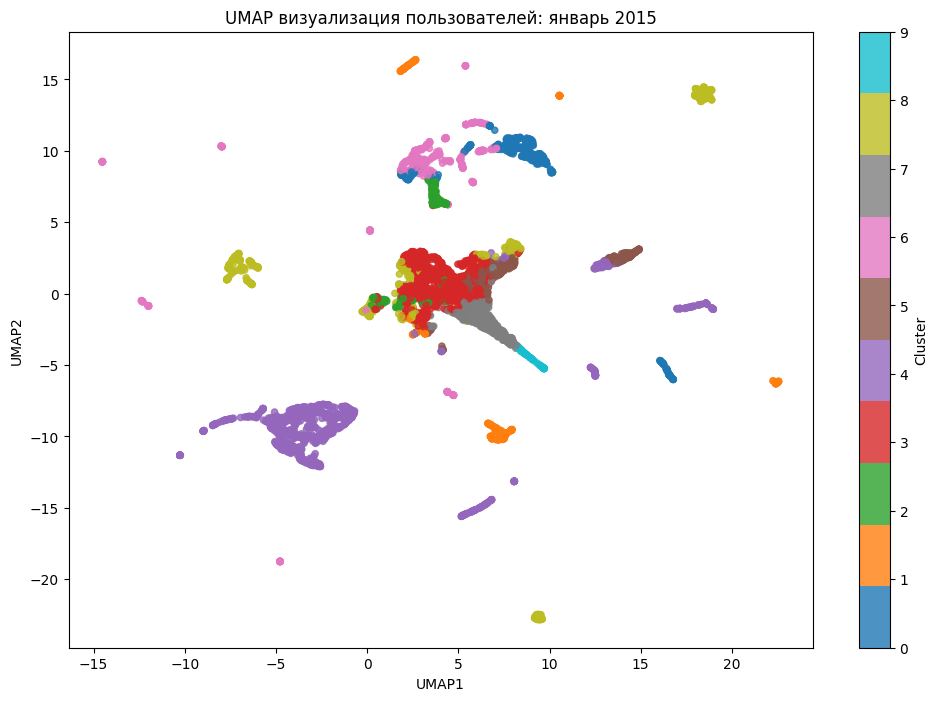

In [45]:
import umap
import matplotlib.pyplot as plt

month_df = all_df[(all_df['year']==2015) & (all_df['month']==1)]
X = month_df[features_cols].values.astype('float32')

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X)

plt.figure(figsize=(12,8))
plt.scatter(
    embedding[:,0], embedding[:,1],
    c=month_df['cluster'],
    cmap=plt.cm.tab10,
    s=20,
    alpha=0.8
)
plt.colorbar(label='Cluster')
plt.title('UMAP визуализация пользователей: январь 2015')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()


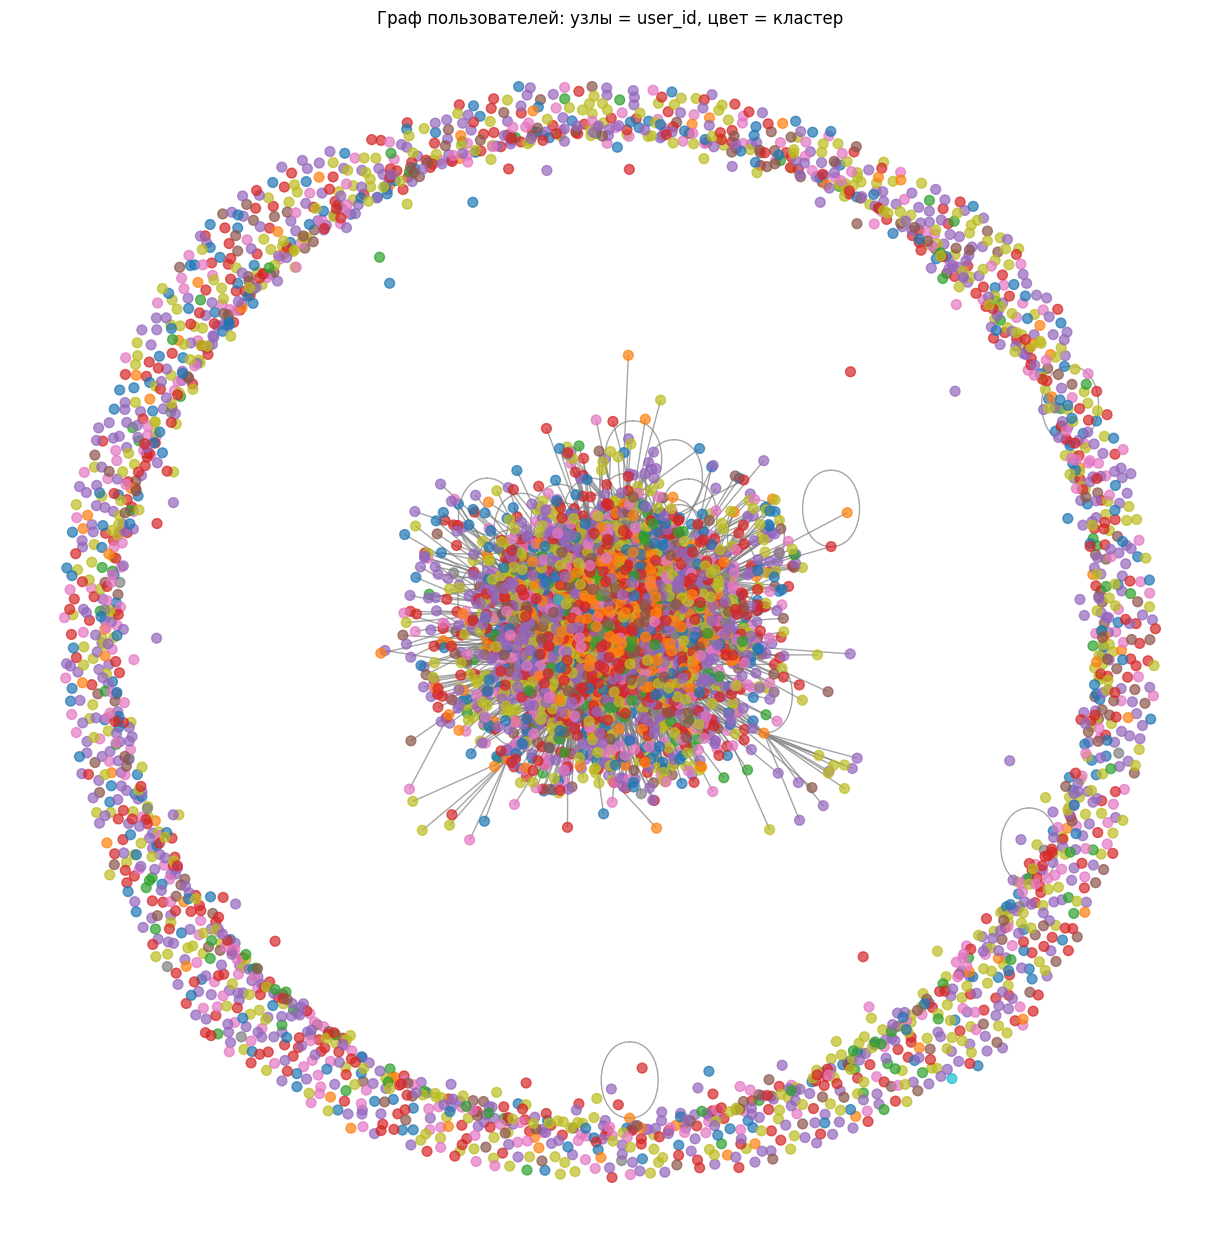

In [65]:
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. Подготовка словаря user_id -> cluster ---
user_to_cluster = df_month.set_index('user_id')['cluster'].to_dict()

# --- 2. Создание графа ---
G = nx.Graph()

# Добавляем узлы с атрибутом cluster
for user_id, cluster in user_to_cluster.items():
    G.add_node(user_id, cluster=int(cluster))

# Добавляем рёбра по взаимодействиям
df_edges = df_month.dropna(subset=['parent_user_id'])
for _, row in df_edges.iterrows():
    u = row['user_id']
    v = row['parent_user_id']
    # добавляем ребро только если оба узла есть в user_to_cluster
    if u in user_to_cluster and v in user_to_cluster:
        G.add_edge(u, v)

# --- 3. Цвета узлов по кластеру ---
node_colors = [G.nodes[n]['cluster'] for n in G.nodes()]

# --- 4. Визуализация ---
plt.figure(figsize=(12,12))
pos = nx.spring_layout(G, seed=42)  # алгоритм размещения узлов
nx.draw(
    G,
    pos,
    node_color=node_colors,
    cmap=plt.cm.tab10,
    node_size=50,
    with_labels=False,
    edge_color='gray',
    alpha=0.7
)
plt.title("Граф пользователей: узлы = user_id, цвет = кластер")
plt.show()


In [67]:
df_month

,post_id,publish_date,user_id,parent_id,parent_user_id,content,url,language,interaction_type,platform,community,strict_filter,sentiment_vader,month,year,cluster
0,a6dfdda4-0034-5975-abaa-ab34b72521bc,2015-01-01 00:01:39+00:00,a886badc-333f-5b7a-ba95-3575c6b3047b,None,None,Academic programs are typically places where i...,None,English,COMMENT,reddit,MensRights,None,0.7253,1,2015,3
1,a6dfdda4-0034-5975-abaa-ab34b72521bc,2015-01-01 00:01:39+00:00,a886badc-333f-5b7a-ba95-3575c6b3047b,None,None,Academic programs are typically places where i...,None,English,COMMENT,reddit,MensRights,None,0.7253,1,2015,0
2,3f2aa3ab-64ca-576e-bc54-cd03ed8441e0,2015-01-01 00:01:46+00:00,8044ac2c-7006-5b11-a430-eb0bb75d9bd3,92d647fd-9ec6-5c2a-9d72-1ea23f2e7789,09040e98-5792-54a5-b2bf-142ba54cfbe2,Watch this: https://www.youtube.com/watch?v=6w...,https://www.youtube.com/watch?v=6wXkI4t7nuc,English,COMMENT,reddit,MensRights,None,0.0000,1,2015,7
3,3f2aa3ab-64ca-576e-bc54-cd03ed8441e0,2015-01-01 00:01:46+00:00,8044ac2c-7006-5b11-a430-eb0bb75d9bd3,92d647fd-9ec6-5c2a-9d72-1ea23f2e7789,09040e98-5792-54a5-b2bf-142ba54cfbe2,Watch this: https://www.youtube.com/watch?v=6w...,https://www.youtube.com/watch?v=6wXkI4t7nuc,English,COMMENT,reddit,MensRights,None,0.0000,1,2015,9
4,3f2aa3ab-64ca-576e-bc54-cd03ed8441e0,2015-01-01 00:01:46+00:00,8044ac2c-7006-5b11-a430-eb0bb75d9bd3,92d647fd-9ec6-5c2a-9d72-1ea23f2e7789,09040e98-5792-54a5-b2bf-142ba54cfbe2,Watch this: https://www.youtube.com/watch?v=6w...,https://www.youtube.com/watch?v=6wXkI4t7nuc,English,COMMENT,reddit,MensRights,None,0.0000,1,2015,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075941,e44a608f-1ac6-592a-a755-9d741cf6195e,2015-01-31 23:59:06+00:00,a2663024-4eba-552d-91f5-92c37d6e892a,None,None,"Hey, not to try and change your mind, but life...",None,English,COMMENT,reddit,MensRights,None,0.9559,1,2015,3
1075942,e44a608f-1ac6-592a-a755-9d741cf6195e,2015-01-31 23:59:06+00:00,a2663024-4eba-552d-91f5-92c37d6e892a,None,None,"Hey, not to try and change your mind, but life...",None,English,COMMENT,reddit,MensRights,None,0.9559,1,2015,4
1075943,e44a608f-1ac6-592a-a755-9d741cf6195e,2015-01-31 23:59:06+00:00,a2663024-4eba-552d-91f5-92c37d6e892a,None,None,"Hey, not to try and change your mind, but life...",None,English,COMMENT,reddit,MensRights,None,0.9559,1,2015,0
1075944,e44a608f-1ac6-592a-a755-9d741cf6195e,2015-01-31 23:59:06+00:00,a2663024-4eba-552d-91f5-92c37d6e892a,None,None,"Hey, not to try and change your mind, but life...",None,English,COMMENT,reddit,MensRights,None,0.9559,1,2015,0


In [73]:
df_month

,post_id,publish_date,user_id,parent_id,parent_user_id,content,url,language,interaction_type,platform,community,strict_filter,sentiment_vader,month,year,cluster
0,a6dfdda4-0034-5975-abaa-ab34b72521bc,2015-01-01 00:01:39+00:00,a886badc-333f-5b7a-ba95-3575c6b3047b,None,None,Academic programs are typically places where i...,None,English,COMMENT,reddit,MensRights,None,0.7253,1,2015,3
1,a6dfdda4-0034-5975-abaa-ab34b72521bc,2015-01-01 00:01:39+00:00,a886badc-333f-5b7a-ba95-3575c6b3047b,None,None,Academic programs are typically places where i...,None,English,COMMENT,reddit,MensRights,None,0.7253,1,2015,0
2,3f2aa3ab-64ca-576e-bc54-cd03ed8441e0,2015-01-01 00:01:46+00:00,8044ac2c-7006-5b11-a430-eb0bb75d9bd3,92d647fd-9ec6-5c2a-9d72-1ea23f2e7789,09040e98-5792-54a5-b2bf-142ba54cfbe2,Watch this: https://www.youtube.com/watch?v=6w...,https://www.youtube.com/watch?v=6wXkI4t7nuc,English,COMMENT,reddit,MensRights,None,0.0000,1,2015,7
3,3f2aa3ab-64ca-576e-bc54-cd03ed8441e0,2015-01-01 00:01:46+00:00,8044ac2c-7006-5b11-a430-eb0bb75d9bd3,92d647fd-9ec6-5c2a-9d72-1ea23f2e7789,09040e98-5792-54a5-b2bf-142ba54cfbe2,Watch this: https://www.youtube.com/watch?v=6w...,https://www.youtube.com/watch?v=6wXkI4t7nuc,English,COMMENT,reddit,MensRights,None,0.0000,1,2015,9
4,3f2aa3ab-64ca-576e-bc54-cd03ed8441e0,2015-01-01 00:01:46+00:00,8044ac2c-7006-5b11-a430-eb0bb75d9bd3,92d647fd-9ec6-5c2a-9d72-1ea23f2e7789,09040e98-5792-54a5-b2bf-142ba54cfbe2,Watch this: https://www.youtube.com/watch?v=6w...,https://www.youtube.com/watch?v=6wXkI4t7nuc,English,COMMENT,reddit,MensRights,None,0.0000,1,2015,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075941,e44a608f-1ac6-592a-a755-9d741cf6195e,2015-01-31 23:59:06+00:00,a2663024-4eba-552d-91f5-92c37d6e892a,None,None,"Hey, not to try and change your mind, but life...",None,English,COMMENT,reddit,MensRights,None,0.9559,1,2015,3
1075942,e44a608f-1ac6-592a-a755-9d741cf6195e,2015-01-31 23:59:06+00:00,a2663024-4eba-552d-91f5-92c37d6e892a,None,None,"Hey, not to try and change your mind, but life...",None,English,COMMENT,reddit,MensRights,None,0.9559,1,2015,4
1075943,e44a608f-1ac6-592a-a755-9d741cf6195e,2015-01-31 23:59:06+00:00,a2663024-4eba-552d-91f5-92c37d6e892a,None,None,"Hey, not to try and change your mind, but life...",None,English,COMMENT,reddit,MensRights,None,0.9559,1,2015,0
1075944,e44a608f-1ac6-592a-a755-9d741cf6195e,2015-01-31 23:59:06+00:00,a2663024-4eba-552d-91f5-92c37d6e892a,None,None,"Hey, not to try and change your mind, but life...",None,English,COMMENT,reddit,MensRights,None,0.9559,1,2015,0


In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# --- 0. Фильтр пользователей по активности (кол-во постов >= 5) ---
user_activity = df_month.groupby('user_id').size()
active_users = user_activity[user_activity >= 1500].index.tolist()
df_active = df_month[df_month['user_id'].isin(active_users)]

# --- 1. Подготовка словаря user_id -> cluster ---
user_to_cluster = df_active.set_index('user_id')['cluster'].fillna(-1).to_dict()

# --- 2. Создание графа ---
G = nx.Graph()

# Добавляем узлы с атрибутом cluster
for user_id, cluster in user_to_cluster.items():
    G.add_node(user_id, cluster=int(cluster))

# Добавляем рёбра по взаимодействиям
df_edges = df_active.dropna(subset=['parent_user_id'])
for _, row in df_edges.iterrows():
    u = row['user_id']
    v = row['parent_user_id']
    if u in user_to_cluster and v in user_to_cluster:
        G.add_edge(u, v)

# --- 3. Цвета узлов по кластеру ---
node_colors = [G.nodes[n]['cluster'] if G.nodes[n]['cluster'] != -1 else 10 for n in G.nodes()]

# --- 4. Визуализация ---
plt.figure(figsize=(12,12))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    node_color=node_colors,
    cmap=plt.cm.tab10,
    node_size=50,
    with_labels=False,
    edge_color='gray',
    alpha=0.7
)
plt.title("Граф активных пользователей (≥5 постов): узлы = user_id, цвет = кластер")
plt.show()


NameError: name 'df_month' is not defined

In [2]:
df_month = df[(df['year']==2015) & (df['month']==1)].copy()
df_month = df_month.merge(
    all_df[['user_id', 'cluster']],
    on='user_id',
    how='left'
)

NameError: name 'df' is not defined

In [62]:
df_month

,post_id,publish_date,user_id,parent_id,parent_user_id,content,url,language,interaction_type,platform,community,strict_filter,sentiment_vader,month,year,cluster
0,a6dfdda4-0034-5975-abaa-ab34b72521bc,2015-01-01 00:01:39+00:00,a886badc-333f-5b7a-ba95-3575c6b3047b,None,None,Academic programs are typically places where i...,None,English,COMMENT,reddit,MensRights,None,0.7253,1,2015,3
1,a6dfdda4-0034-5975-abaa-ab34b72521bc,2015-01-01 00:01:39+00:00,a886badc-333f-5b7a-ba95-3575c6b3047b,None,None,Academic programs are typically places where i...,None,English,COMMENT,reddit,MensRights,None,0.7253,1,2015,0
2,3f2aa3ab-64ca-576e-bc54-cd03ed8441e0,2015-01-01 00:01:46+00:00,8044ac2c-7006-5b11-a430-eb0bb75d9bd3,92d647fd-9ec6-5c2a-9d72-1ea23f2e7789,09040e98-5792-54a5-b2bf-142ba54cfbe2,Watch this: https://www.youtube.com/watch?v=6w...,https://www.youtube.com/watch?v=6wXkI4t7nuc,English,COMMENT,reddit,MensRights,None,0.0000,1,2015,7
3,3f2aa3ab-64ca-576e-bc54-cd03ed8441e0,2015-01-01 00:01:46+00:00,8044ac2c-7006-5b11-a430-eb0bb75d9bd3,92d647fd-9ec6-5c2a-9d72-1ea23f2e7789,09040e98-5792-54a5-b2bf-142ba54cfbe2,Watch this: https://www.youtube.com/watch?v=6w...,https://www.youtube.com/watch?v=6wXkI4t7nuc,English,COMMENT,reddit,MensRights,None,0.0000,1,2015,9
4,3f2aa3ab-64ca-576e-bc54-cd03ed8441e0,2015-01-01 00:01:46+00:00,8044ac2c-7006-5b11-a430-eb0bb75d9bd3,92d647fd-9ec6-5c2a-9d72-1ea23f2e7789,09040e98-5792-54a5-b2bf-142ba54cfbe2,Watch this: https://www.youtube.com/watch?v=6w...,https://www.youtube.com/watch?v=6wXkI4t7nuc,English,COMMENT,reddit,MensRights,None,0.0000,1,2015,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075941,e44a608f-1ac6-592a-a755-9d741cf6195e,2015-01-31 23:59:06+00:00,a2663024-4eba-552d-91f5-92c37d6e892a,None,None,"Hey, not to try and change your mind, but life...",None,English,COMMENT,reddit,MensRights,None,0.9559,1,2015,3
1075942,e44a608f-1ac6-592a-a755-9d741cf6195e,2015-01-31 23:59:06+00:00,a2663024-4eba-552d-91f5-92c37d6e892a,None,None,"Hey, not to try and change your mind, but life...",None,English,COMMENT,reddit,MensRights,None,0.9559,1,2015,4
1075943,e44a608f-1ac6-592a-a755-9d741cf6195e,2015-01-31 23:59:06+00:00,a2663024-4eba-552d-91f5-92c37d6e892a,None,None,"Hey, not to try and change your mind, but life...",None,English,COMMENT,reddit,MensRights,None,0.9559,1,2015,0
1075944,e44a608f-1ac6-592a-a755-9d741cf6195e,2015-01-31 23:59:06+00:00,a2663024-4eba-552d-91f5-92c37d6e892a,None,None,"Hey, not to try and change your mind, but life...",None,English,COMMENT,reddit,MensRights,None,0.9559,1,2015,0
